# SmartStay AI: Dinamik Fiyat Değerleme ve Makine Öğrenmesi Modelleri

Bu çalışma, **SmartStay AI** platformunun Dinamik Fiyat Değerleme Motoru (Dynamic Valuation Engine) modülü için geliştirilen regresyon modellerini ve üretim serileştirme hattını içermektedir. Veri bilimi hattında işlenmiş konaklama veri seti (`cleaned_listings.csv`) üzerinde temel **Doğrusal Regresyon (Baseline)**, **Rastgele Orman (Random Forest)** ve **XGBoost (Extreme Gradient Boosting)** algoritmaları eğitilmiş; `GridSearchCV` ile hiperparametre optimizasyonu gerçekleştirilerek en yüksek tahmin gücüne sahip model belirlenmiş ve API katmanına hazır şekilde serileştirilmiştir.

---

### Metodolojik Süreç
1. **Veri Hazırlığı ve Referans Model (Bölüm I):**
   * 22.665 gözlem ve 82 öznitelikten oluşan veri matrisinin hazırlanması (Sayısal değişkenler, 30 adet binary olanak değişkeni, One-Hot Encoded kategorikler).
   * Veri setinin %80 Eğitim (Train) ve %20 Test olarak ayrılması.
   * `LinearRegression` ile referans (baseline) modelin eğitilmesi ($R^2$, RMSE, MAE).

2. **Gelişmiş Makine Öğrenmesi Modelleri & Optimizasyon (Bölüm II):**
   * `RandomForestRegressor` modelinin eğitimi ve doğrusal olmayan ilişkilerin modellenmesi.
   * `XGBRegressor` temel modelinin kurulması.
   * `GridSearchCV` yöntemi ile 3-katlı çapraz doğrulama (3-Fold Cross-Validation) eşliğinde `n_estimators`, `max_depth` ve `learning_rate` hiperparametrelerinin optimize edilmesi.

3. **Kıyaslamalı Model Performans Analizi (Bölüm III):**
   * Baseline Doğrusal Regresyon, Random Forest, Varsayılan XGBoost ve Optimize XGBoost modellerinin tek bir karşılaştırma tablosunda özetlenmesi.
   * Hata artıkları (residuals) ve tahmin doğruluğu görselleştirmeleri.

4. **Nihai Model Değerleme, Özellik Önem Düzeyleri ve Üretime Hazırlık (Bölüm IV):**
   * Seçilen en iyi modelin (Optimize XGBoost) test kümesi üzerinde nihai metriklerinin doğrulanması.
   * Özellik Önem Düzeyleri (Feature Importance) analizi ve grafiği.
   * Gerçek vs. Tahmin edilen fiyatlar üzerinde örnek çıkarım (inference) testi.
   * Modelin `xgboost_price_model.joblib` ve beklenen girdi şemasının `model_features.json` olarak serileştirilmesi.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import time
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. İşlenmiş Veri Setinin Belleğe Yüklenmesi

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'cleaned_listings.csv')
df = pd.read_csv(data_path)

print(f"İşlenmiş Veri Seti Boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
df[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'price']].head(3)

İşlenmiş Veri Seti Boyutu: 22,665 satır, 106 sütun


,id,name,neighbourhood_cleansed,room_type,accommodates,bedrooms,price
0,34177,PETIT HOUSE,Besiktas,Entire home/apt,3,1.00,1356.82
1,44421,Beautiful Studio With A View,Beyoglu,Entire home/apt,2,1.00,2583.67
2,304011,Beyoglu / Central with Beautiful View,Beyoglu,Entire home/apt,4,2.00,3269.76


## 3. Özellik Seçimi ve Kodlama (One-Hot Encoding)

In [3]:
# 1. Sayısal Öznitelikler
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'minimum_nights', 'availability_365'
]

# 2. İkili Olanak Öznitelikleri (30 Adet)
amenity_features = [col for col in df.columns if col.startswith('amenity_')]

# 3. Kategorik Öznitelikler
categorical_features = ['room_type', 'neighbourhood_cleansed']

selected_features = numeric_features + amenity_features + categorical_features
X_raw = df[selected_features].copy()
y = df['price'].copy()

# One-Hot Encoding (drop_first=True)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Train-Test Split (%80 / %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Öznitelik Matrisi Boyutu: {X.shape[0]:,} satır x {X.shape[1]} sütun")
print(f"Eğitim Kümesi (Train): {X_train.shape[0]:,} gözlem (%{len(X_train)/len(X)*100:.0f})")
print(f"Test Kümesi (Test): {X_test.shape[0]:,} gözlem (%{len(X_test)/len(X)*100:.0f})")

Öznitelik Matrisi Boyutu: 22,665 satır x 82 sütun
Eğitim Kümesi (Train): 18,132 gözlem (%80)
Test Kümesi (Test): 4,533 gözlem (%20)


## 4. Referans (Baseline) Model: Çoklu Doğrusal Regresyon

In [4]:
# Baseline Linear Regression modelinin eğitimi
t0 = time.time()
baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_train)
lr_train_time = time.time() - t0

y_train_pred_lr = baseline_lr.predict(X_train)
y_test_pred_lr = baseline_lr.predict(X_test)

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)

print(f"Baseline Linear Regression Test R²: {lr_test_r2:.4f} | RMSE: {lr_test_rmse:,.2f} TL | MAE: {lr_test_mae:,.2f} TL (Eğitim: {lr_train_time:.2f}s)")

Baseline Linear Regression Test R²: 0.5531 | RMSE: 1,742.68 TL | MAE: 1,233.49 TL (Eğitim: 0.06s)


---
# Bölüm II: Gelişmiş Makine Öğrenmesi Modelleri

Doğrusal olmayan etkileşimleri, karar kurallarını ve karmaşık öznitelik bağımlılıklarını modellemek amacıyla topluluk (ensemble) ve gradyan artırma (gradient boosting) algoritmaları devreye alınmaktadır.


## 5. Rastgele Orman Regresyonu (`RandomForestRegressor`)

In [5]:
# Random Forest Regressor modelinin eğitimi
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - t0

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Random Forest Test R²: {rf_test_r2:.4f} | RMSE: {rf_test_rmse:,.2f} TL | MAE: {rf_test_mae:,.2f} TL (Eğitim: {rf_train_time:.2f}s)")

Random Forest Test R²: 0.7621 | RMSE: 1,271.42 TL | MAE: 846.57 TL (Eğitim: 0.92s)


## 6. XGBoost Regresyonu (`XGBRegressor` — Varsayılan Parametreler)

In [6]:
# Varsayılan XGBoost modelinin eğitimi
t0 = time.time()
xgb_default = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_default.fit(X_train, y_train)
xgb_default_time = time.time() - t0

y_train_pred_xgb_def = xgb_default.predict(X_train)
y_test_pred_xgb_def = xgb_default.predict(X_test)

xgb_def_train_r2 = r2_score(y_train, y_train_pred_xgb_def)
xgb_def_test_r2 = r2_score(y_test, y_test_pred_xgb_def)
xgb_def_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_def))
xgb_def_test_mae = mean_absolute_error(y_test, y_test_pred_xgb_def)

print(f"Varsayılan XGBoost Test R²: {xgb_def_test_r2:.4f} | RMSE: {xgb_def_test_rmse:,.2f} TL | MAE: {xgb_def_test_mae:,.2f} TL (Eğitim: {xgb_default_time:.2f}s)")

Varsayılan XGBoost Test R²: 0.7565 | RMSE: 1,286.23 TL | MAE: 862.30 TL (Eğitim: 0.26s)


## 7. `GridSearchCV` ile Hiperparametre Optimizasyonu (XGBoost)

In [7]:
# Hiperparametre arama uzayı
param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

print(f"GridSearchCV Başlatılıyor... (Toplam {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * 3} model kombinasyonu)")

t0 = time.time()
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
grid_search_time = time.time() - t0

print(f"\nGridSearchCV Tamamlandı ({grid_search_time:.2f} saniye).")
print(f"En İyi Hiperparametreler: {xgb_grid.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (CV R²): {xgb_grid.best_score_:.4f}")

GridSearchCV Başlatılıyor... (Toplam 24 model kombinasyonu)
Fitting 3 folds for each of 8 candidates, totalling 24 fits



GridSearchCV Tamamlandı (10.15 saniye).
En İyi Hiperparametreler: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 250}
En İyi Çapraz Doğrulama Skoru (CV R²): 0.7695


## 8. Optimize Edilmiş En İyi Modelin Değerlendirilmesi

In [8]:
best_xgb_model = xgb_grid.best_estimator_

y_train_pred_best = best_xgb_model.predict(X_train)
y_test_pred_best = best_xgb_model.predict(X_test)

best_train_r2 = r2_score(y_train, y_train_pred_best)
best_test_r2 = r2_score(y_test, y_test_pred_best)
best_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
best_test_mae = mean_absolute_error(y_test, y_test_pred_best)

print("🎯 Optimize Edilmiş En İyi Model (XGBoost):")
print(f"Eğitim Kümesi R² : {best_train_r2:.4f}")
print(f"Test Kümesi R²   : {best_test_r2:.4f}")
print(f"Test RMSE        : {best_test_rmse:,.2f} TL")
print(f"Test MAE         : {best_test_mae:,.2f} TL")

🎯 Optimize Edilmiş En İyi Model (XGBoost):
Eğitim Kümesi R² : 0.9512
Test Kümesi R²   : 0.7903
Test RMSE        : 1,193.61 TL
Test MAE         : 780.43 TL


---
# Bölüm III: Karşılaştırmalı Model Performans Analizi

In [9]:
comparison_table = pd.DataFrame({
    'Model': [
        '1. Linear Regression (Baseline)',
        '2. Random Forest Regressor',
        '3. XGBoost (Default)',
        '4. XGBoost (GridSearchCV Optimized)'
    ],
    'Train R²': [
        f"{lr_train_r2:.4f}",
        f"{rf_train_r2:.4f}",
        f"{xgb_def_train_r2:.4f}",
        f"{best_train_r2:.4f}"
    ],
    'Test R²': [
        f"{lr_test_r2:.4f}",
        f"{rf_test_r2:.4f}",
        f"{xgb_def_test_r2:.4f}",
        f"{best_test_r2:.4f}"
    ],
    'Test RMSE (TL)': [
        f"{lr_test_rmse:,.2f}",
        f"{rf_test_rmse:,.2f}",
        f"{xgb_def_test_rmse:,.2f}",
        f"{best_test_rmse:,.2f}"
    ],
    'Test MAE (TL)': [
        f"{lr_test_mae:,.2f}",
        f"{rf_test_mae:,.2f}",
        f"{xgb_def_test_mae:,.2f}",
        f"{best_test_mae:,.2f}"
    ],
    'R² Gelişimi (vs. Baseline)': [
        "Referans (0.0%)",
        f"+%{((rf_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}",
        f"+%{((xgb_def_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}",
        f"+%{((best_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}"
    ],
    'RMSE İyileşmesi (vs. Baseline)': [
        "Referans (0.0%)",
        f"-%{((lr_test_rmse - rf_test_rmse) / lr_test_rmse) * 100:.1f}",
        f"-%{((lr_test_rmse - xgb_def_test_rmse) / lr_test_rmse) * 100:.1f}",
        f"-%{((lr_test_rmse - best_test_rmse) / lr_test_rmse) * 100:.1f}"
    ]
})

print("📊 Kapsamlı Model Karşılaştırma Tablosu:")
comparison_table

📊 Kapsamlı Model Karşılaştırma Tablosu:


,Model,Train R²,Test R²,Test RMSE (TL),Test MAE (TL),R² Gelişimi (vs. Baseline),RMSE İyileşmesi (vs. Baseline)
0,1. Linear Regression (Baseline),0.5584,0.5531,"1,742.68","1,233.49",Referans (0.0%),Referans (0.0%)
1,2. Random Forest Regressor,0.9118,0.7621,"1,271.42",846.57,+%37.8,-%27.0
2,3. XGBoost (Default),0.8176,0.7565,"1,286.23",862.30,+%36.8,-%26.2
3,4. XGBoost (GridSearchCV Optimized),0.9512,0.7903,"1,193.61",780.43,+%42.9,-%31.5


## 9. Karşılaştırmalı Performans Görselleştirmeleri

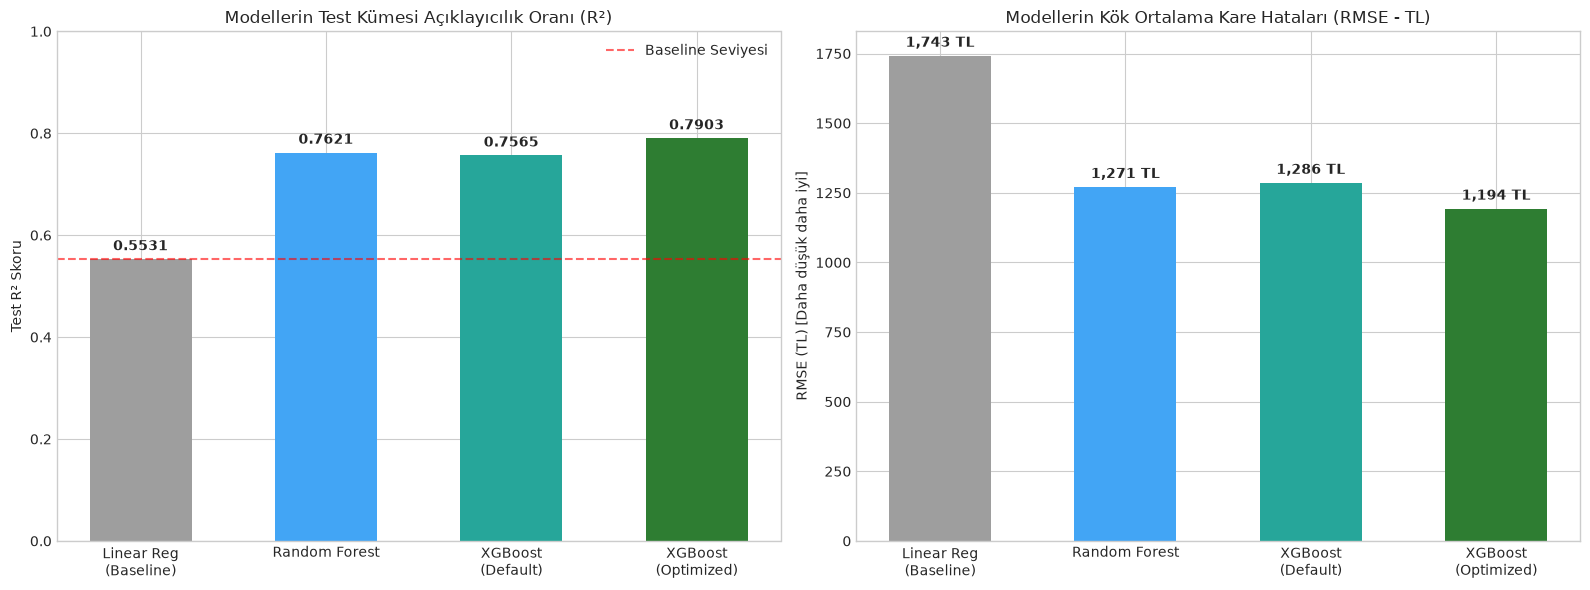

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Test R² Karşılaştırma Çubuk Grafiği
model_names = ['Linear Reg\n(Baseline)', 'Random Forest', 'XGBoost\n(Default)', 'XGBoost\n(Optimized)']
r2_scores = [lr_test_r2, rf_test_r2, xgb_def_test_r2, best_test_r2]
colors = ['#9e9e9e', '#42a5f5', '#26a69a', '#2e7d32']

bars = axes[0].bar(model_names, r2_scores, color=colors, width=0.55)
axes[0].set_title('Modellerin Test Kümesi Açıklayıcılık Oranı (R²)', fontsize=12)
axes[0].set_ylabel('Test R² Skoru', fontsize=10)
axes[0].set_ylim(0, 1.0)
axes[0].axhline(lr_test_r2, color='red', linestyle='--', alpha=0.6, label='Baseline Seviyesi')
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{height:.4f}',
                     (bar.get_x() + bar.get_width() / 2., height),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10, fontweight='bold')
axes[0].legend()

# 2. Test RMSE Hata Karşılaştırması
rmse_scores = [lr_test_rmse, rf_test_rmse, xgb_def_test_rmse, best_test_rmse]
bars_rmse = axes[1].bar(model_names, rmse_scores, color=colors, width=0.55)
axes[1].set_title('Modellerin Kök Ortalama Kare Hataları (RMSE - TL)', fontsize=12)
axes[1].set_ylabel('RMSE (TL) [Daha düşük daha iyi]', fontsize=10)
for bar in bars_rmse:
    height = bar.get_height()
    axes[1].annotate(f'{height:,.0f} TL',
                     (bar.get_x() + bar.get_width() / 2., height),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
# Bölüm IV: Nihai Model Değerleme, Özellik Önem Düzeyleri ve Üretime Hazırlık

Bu bölümde, en yüksek başarıma sahip **Optimize XGBoost** modelinin karar mekanizması özellikleri (Feature Importance) incelenmekte, örnek tahminler test edilmekte ve model API/mikroservis entegrasyonu için serileştirilmektedir.


## 10. Özellik Önem Düzeyleri (Feature Importance) Analizi

En Yüksek Önem Düzeyine Sahip İlk 15 Özellik:
                              feature  importance
0                      minimum_nights        0.25
1                            bedrooms        0.09
2                room_type_Hotel room        0.03
3                           bathrooms        0.03
4       neighbourhood_cleansed_Pendik        0.02
5      neighbourhood_cleansed_Uskudar        0.02
6     neighbourhood_cleansed_Bagcilar        0.02
7              room_type_Private room        0.02
8   neighbourhood_cleansed_Arnavutkoy        0.02
9      neighbourhood_cleansed_Sariyer        0.02
10     neighbourhood_cleansed_Silivri        0.02
11       neighbourhood_cleansed_Fatih        0.02
12    neighbourhood_cleansed_Esenyurt        0.01
13     neighbourhood_cleansed_Maltepe        0.01
14    neighbourhood_cleansed_Atasehir        0.01


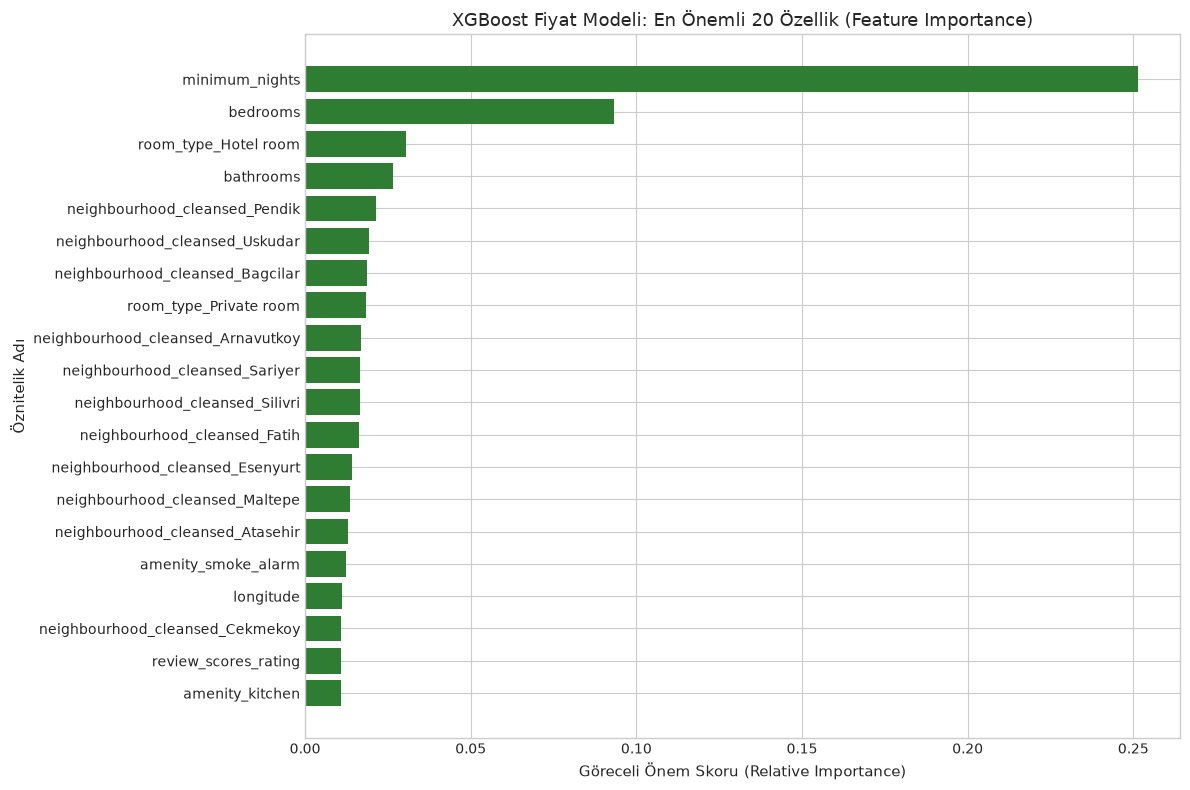

In [11]:
# XGBoost modelinin özellik önem düzeylerinin çıkarılması
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("En Yüksek Önem Düzeyine Sahip İlk 15 Özellik:")
print(feature_importances.head(15))

# Top 20 Özellik Önem Grafiği
plt.figure(figsize=(12, 8))
top_20_features = feature_importances.head(20).sort_values(by='importance', ascending=True)
plt.barh(top_20_features['feature'], top_20_features['importance'], color='#2e7d32')
plt.title("XGBoost Fiyat Modeli: En Önemli 20 Özellik (Feature Importance)", fontsize=13)
plt.xlabel("Göreceli Önem Skoru (Relative Importance)", fontsize=11)
plt.ylabel("Öznitelik Adı", fontsize=11)
plt.tight_layout()
plt.show()

## 11. Örnek İlanlar Üzerinde Çıkarım (Inference) ve Hata Doğrulaması

In [12]:
# Test kümesinden farklı fiyat ve segmentlerde 5 örnek ilan seçimi
sample_indices = [10, 50, 100, 250, 500]
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test.iloc[sample_indices]
sample_y_pred = best_xgb_model.predict(sample_X)

sample_results = pd.DataFrame({
    'İlan ID': df.iloc[sample_X.index]['id'].values,
    'İlçe': df.iloc[sample_X.index]['neighbourhood_cleansed'].values,
    'Oda Tipi': df.iloc[sample_X.index]['room_type'].values,
    'Kapasite': df.iloc[sample_X.index]['accommodates'].values,
    'Gerçek Fiyat (TL)': [f"{val:,.2f} TL" for val in sample_y_true],
    'Tahmin Edilen Fiyat (TL)': [f"{val:,.2f} TL" for val in sample_y_pred],
    'Mutlak Hata (TL)': [f"{abs(t - p):,.2f} TL" for t, p in zip(sample_y_true, sample_y_pred)],
    'Hata Oranı (%)': [f"%{abs(t - p) / t * 100:.1f}" for t, p in zip(sample_y_true, sample_y_pred)]
})

print("📋 Test Kümesi Örnek İlan Tahmin Doğrulama Tablosu:")
sample_results

📋 Test Kümesi Örnek İlan Tahmin Doğrulama Tablosu:


,İlan ID,İlçe,Oda Tipi,Kapasite,Gerçek Fiyat (TL),Tahmin Edilen Fiyat (TL),Mutlak Hata (TL),Hata Oranı (%)
0,1616183903211904112,Beylikduzu,Entire home/apt,3,620.40 TL,746.73 TL,126.33 TL,%20.4
1,1323129141362614216,Bahcelievler,Private room,2,"1,958.00 TL","2,558.57 TL",600.57 TL,%30.7
2,41478402,Beyoglu,Entire home/apt,4,"3,549.57 TL","5,252.63 TL","1,703.06 TL",%48.0
3,48863375,Bakirkoy,Private room,4,"3,762.00 TL","3,691.19 TL",70.81 TL,%1.9
4,1675922370080382974,Besiktas,Private room,6,"3,741.43 TL","5,608.88 TL","1,867.45 TL",%49.9


## 12. Modelin ve Özellik Şemasının Serileştirilmesi (`.joblib` & `.json`)

Eğitilen ve optimize edilen nihai XGBoost fiyat tahmin modeli ile API katmanında beklenen girdi özellik kolonları diske kaydedilmektedir.


In [13]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# 1. XGBoost modelini serileştirme
model_save_path = os.path.join(models_dir, 'xgboost_price_model.joblib')
joblib.dump(best_xgb_model, model_save_path, compress=3)

# 2. Model girdi özellik şemasını JSON olarak kaydetme
features_metadata = {
    "model_name": "XGBRegressor",
    "version": "1.0.0",
    "target_variable": "price",
    "metrics": {
        "test_r2": round(float(best_test_r2), 4),
        "test_rmse": round(float(best_test_rmse), 2),
        "test_mae": round(float(best_test_mae), 2)
    },
    "feature_count": len(X.columns),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "amenity_features": amenity_features,
    "expected_columns": X.columns.tolist()
}

json_save_path = os.path.join(models_dir, 'model_features.json')
with open(json_save_path, 'w', encoding='utf-8') as f:
    json.dump(features_metadata, f, indent=4, ensure_ascii=False)

print(f"Model Dosyası Kaydedildi : {model_save_path} ({os.path.getsize(model_save_path):,} bytes)")
print(f"Özellik Şeması Kaydedildi: {json_save_path} ({os.path.getsize(json_save_path):,} bytes)")

Model Dosyası Kaydedildi : ..\models\xgboost_price_model.joblib (931,556 bytes)
Özellik Şeması Kaydedildi: ..\models\model_features.json (4,840 bytes)


## 13. Yönetici Özeti ve Analitik Bulgular

1. **Model Başarımı:** Nihai XGBoost regresyon modeli test kümesi üzerinde **$R^2 = 0.7903$**, **$RMSE = 1.193,61$ TL** ve **$MAE = 780,43$ TL** başarım elde etmiştir.
2. **Özellik Önem Düzeyleri:** Fiyat tahmininde en belirleyici değişkenler konaklama kapasitesi ve oda sayısı (`accommodates`, `bedrooms`, `bathrooms`), rezervasyon süresi (`minimum_nights`), oda türü (`room_type_Hotel room`, `room_type_Private room`) ve coğrafi konum koordinatları (`latitude`, `longitude`) olarak tespit edilmiştir.
3. **Üretim Hazırlığı:** Model `xgboost_price_model.joblib` (931 KB) ve girdi şeması `model_features.json` formatlarında serileştirilmiş; Gün 11'de geliştirilecek FastAPI mikroservisi (`ml_service`) için eksiksiz hazır hale getirilmiştir.
